**Multi Class Classification with MNIST Dataset**

In [1]:
import tensorflow as tf
tf.__version__

'2.19.0'

In [2]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [3]:
(X_train, y_train), (X_test, y_test) = load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [6]:
set(y_train)

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

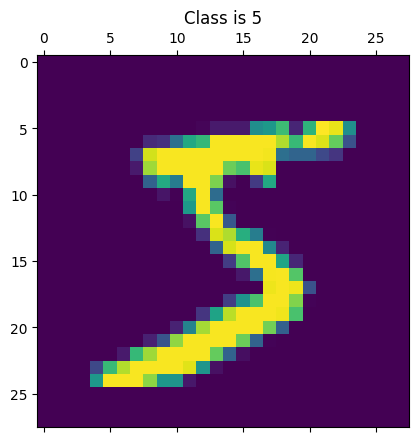

In [8]:
 #Visualization
 import matplotlib.pyplot as plt
 plt.matshow(X_train[0])
 plt.title(f"Class is {y_train[0]}")
 plt.show()

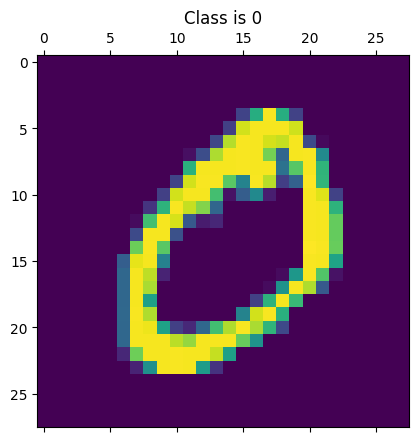

In [9]:
 #Visualization
 import matplotlib.pyplot as plt
 plt.matshow(X_train[1])
 plt.title(f"Class is {y_train[1]}")
 plt.show()

In [10]:
# Preprocessing
# 0 to 255
import numpy as np
np.max(X_train), np.min(X_train)

(np.uint8(255), np.uint8(0))

In [11]:
X_train = X_train / 255
X_test = X_test / 255

In [12]:
np.max(X_train), np.min(X_train)

(np.float64(1.0), np.float64(0.0))

In [13]:
np.max(X_test), np.min(X_test)

(np.float64(1.0), np.float64(0.0))

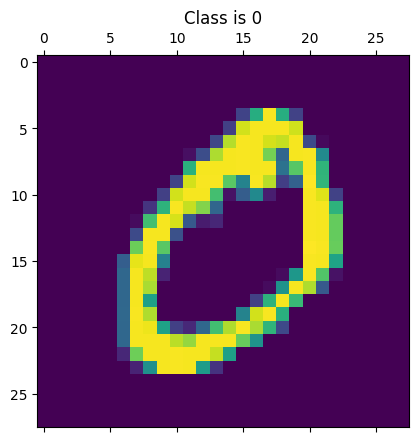

In [15]:
#Visualization
import matplotlib.pyplot as plt
plt.matshow(X_train[1])
plt.title(f"Class is {y_train[1]}")
plt.show()

In [16]:
28*28

784

In [17]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

In [18]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [20]:
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [21]:
y_train[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [23]:
# Model
model = Sequential()
model.add(Dense(256, activation='relu', input_shape=[784,], name ="h1"))
model.add(Dense(128, activation = 'relu', name = "h2"))
model.add(Dense(10, activation = 'softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.layers[0].get_weights()

[array([[-0.03142263,  0.0672393 ,  0.06479017, ..., -0.03595967,
          0.04332292,  0.05106734],
        [ 0.01741244,  0.01109809, -0.02906216, ..., -0.06769221,
         -0.069436  ,  0.07305153],
        [ 0.00462846, -0.02703222, -0.02064249, ...,  0.0053464 ,
          0.07197148,  0.06844305],
        ...,
        [ 0.03380048,  0.01833203, -0.04753128, ..., -0.00523537,
          0.03547024,  0.02591463],
        [ 0.03109813, -0.01789438,  0.05709732, ...,  0.05803949,
          0.02322384, -0.00799063],
        [-0.05257525,  0.07168694, -0.05409995, ...,  0.05805348,
         -0.03317055,  0.06684752]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [25]:
model.compile(optimizer = 'rmsprop',
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

In [27]:
history = model.fit(x = X_train, y = y_train,
                    epochs = 25,
                    batch_size = 32,
                    validation_data = (X_test, y_test))

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8947 - loss: 0.3479 - val_accuracy: 0.9640 - val_loss: 0.1221
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9723 - loss: 0.0924 - val_accuracy: 0.9755 - val_loss: 0.0852
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9803 - loss: 0.0647 - val_accuracy: 0.9708 - val_loss: 0.1148
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9861 - loss: 0.0475 - val_accuracy: 0.9773 - val_loss: 0.0910
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9883 - loss: 0.0397 - val_accuracy: 0.9789 - val_loss: 0.0916
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9909 - loss: 0.0338 - val_accuracy: 0.9753 - val_loss: 0.1063
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9921 - loss: 0.0277 - val_accuracy: 0.9788 - val_loss: 0.0982
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9933 - loss: 0.

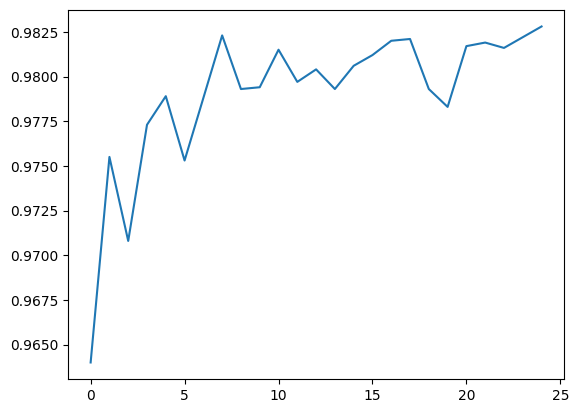

In [28]:
h = history.history

plt.plot(h['val_accuracy'], label = 'validation_accuracy')
plt.plot(h['accuracy'], label = 'train_accuracy')
plt.legend()
plt.show()

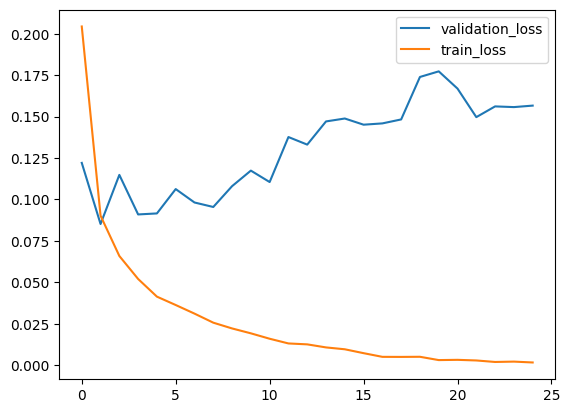

In [29]:
plt.plot(h['val_loss'], label = 'validation_loss')
plt.plot(h['loss'], label = 'train_loss')
plt.legend()
plt.show()

In [30]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9800 - loss: 0.1925


[0.1566646844148636, 0.9828000068664551]